#### Previo
Se importan los paquetes y se aplica el formato general

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as wid
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
import colorcet as cc
import os
import copy
from matplotlib.patches import FancyBboxPatch
import uncertainties as un
from uncertainties.umath import *

Se configuran las gráficas, tengase en cuenta que algunos pueden no cargar por dependencias a instalar pendientes.


In [3]:
%matplotlib widget
mpl.rcParams.update(
    {
        "legend.fontsize": 20,
        "axes.labelsize": 24,  # Updated from 20 to 24
        "axes.titlesize": 24,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "figure.titlesize": 24,
        "axes.titlepad": 10,
        "text.usetex": True,
        "font.family": "Times New Roman",
        "mathtext.fontset": "dejavusans",
        "font.size": 20,
        "axes.labelweight": "bold",
        "axes.grid.which": "both",
        "axes.grid": True,
        "grid.alpha": 0.5,
        "axes.formatter.limits": (-3, 3),  # Use scientific notation for values outside the range 10^-3 to 10^3
        'figure.subplot.bottom': 0.2  
    }
)

colors = cc.glasbey_category10
# Configuracion de colores
k = 0

# Rotar la lista: número positivo para rotar a la derecha, negativo para rotar a la izquierda
colors = colors[-k:] + colors[:-k]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=colors)

# Test
if False:
    plt.figure(figsize=(5, 5))
    plt.plot([1, 2, 3, 4], [1, 4, 9, 16], "o")
    plt.plot([4, 3, 2, 1], [1, 2, 3, 4], "o")
    plt.plot([1, 2, 3, 4], [1, 2, 3, 4], "s")
    plt.plot([4, 3, 2, 1], [1, 4, 9, 16], "s")
    plt.title("Test")
    plt.xlabel("X-axis Label", fontweight="bold")
    plt.ylabel("Y-axis Label")
    plt.show()

# Práctica 8: Difracción

Por Andrés Felipe Pinzón Harker
    Cristian Camilo Perez Puentes

Universidad Nacional de Colombia. Departamento de Física.

Mediciones en Óptica y Acústica

## Introducción

## Metodología Experimental

## Análisis y Resultados

Al realizar los perfiles de luminancia de los patrones de difracción

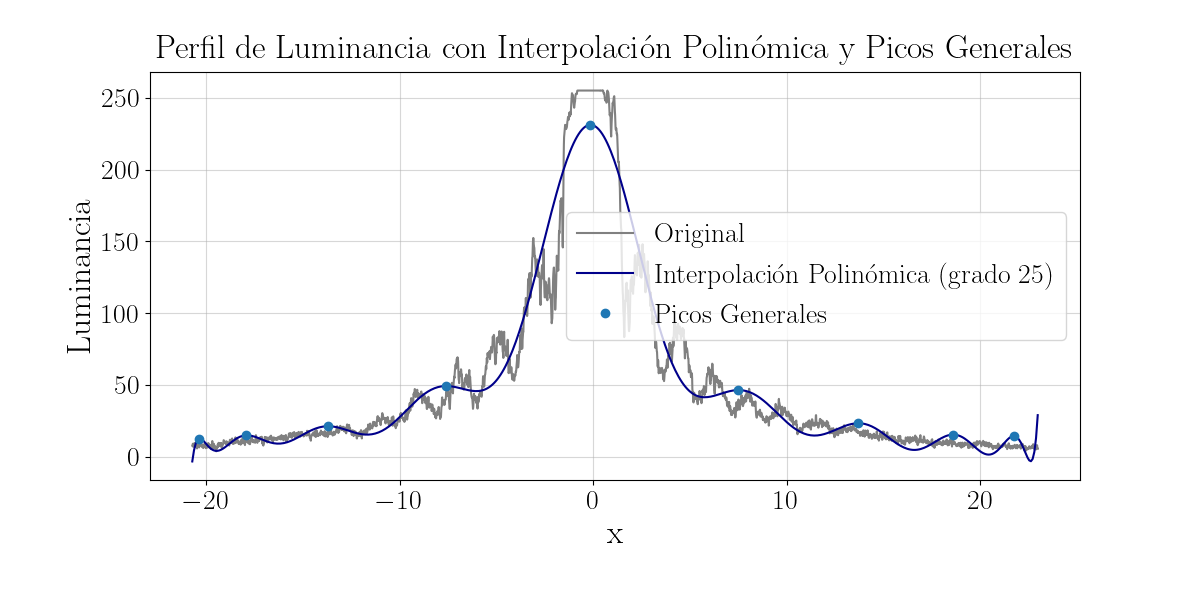

In [94]:
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

pre_dir = "data/"
files = ["perfil_F3_P1.dat", "perfil_F3_P2.dat", "perfil_F3_P3.dat", "perfil_F3_P4.dat"]
data_F3 = {}

for file in files:
    df = pd.read_csv(pre_dir + file, usecols=[1, 2], skiprows=1)
    data_F3[file[:-4]] = df

# Graficar el primer DataFrame
plt.figure(figsize=(12, 6))
plt.plot(data_F3["perfil_F3_P1"]["x"], data_F3["perfil_F3_P1"]["luma"], color="gray", label="Original")

# Interpolación polinómica de alto grado con un grado más alto para ajustar mejor
poly_interp = np.poly1d(np.polyfit(data_F3["perfil_F3_P1"]["x"], data_F3["perfil_F3_P1"]["luma"], deg=20))
x_interp = np.linspace(min(data_F3["perfil_F3_P1"]["x"]), max(data_F3["perfil_F3_P1"]["x"]), 500)
y_interp = poly_interp(x_interp)
plt.plot(x_interp, y_interp, color="darkblue", label="Interpolación Polinómica (grado 25)")

# Encontrar los picos más generales
general_peaks, _ = find_peaks(y_interp, distance=20)
plt.plot(x_interp[general_peaks], y_interp[general_peaks], "o", label="Picos Generales")

plt.legend()
plt.xlabel("x")
plt.ylabel("Luminancia")
plt.title("Perfil de Luminancia con Interpolación Polinómica y Picos Generales")
plt.show()

In [69]:
# Simulación de datos
df = data_F3["perfil_F3_P1"]

# Función de ajuste
def intensidad(x, I0, wx, d):
    lambda_ = 635e-7
    numerador = np.sin(2 * np.pi * wx * x / (lambda_ * d))
    denominador = 2 * np.pi * wx * x / (lambda_ * d)
    return I0 * (numerador / denominador) ** 2

x_fit = np.linspace(min(df["x"]), max(df["x"]), 1000)

# Sliders
I0_slider = wid.FloatSlider(value=8e3, min=1e3, max=1e4, step=1e2, description='I0')
wx_slider = wid.FloatSlider(value=2e-5, min=1e-6, max=1e-4, step=1e-6, description='wx')
d_slider = wid.FloatSlider(value=1, min=0.1, max=10, step=0.1, description='d')

# Función para actualizar la gráfica
def update_plot(I0, wx, d):
    plt.clf()  # Limpia la figura
    y_fit = intensidad(x_fit, I0, wx, d)
    plt.plot(df["x"], df["luma"], lw=0.8, label="Perfil")
    plt.plot(x_fit, y_fit, color="r", lw=2, label="Ajuste")
    plt.ylim(0, 200)
    plt.legend()
    plt.show()

# Conexión de sliders con la función de actualización
out = wid.interactive_output(update_plot, {'I0': I0_slider, 'wx': wx_slider, 'd': d_slider})

# Mostrar sliders y salida interactiva
display(I0_slider, wx_slider, d_slider, out)


FloatSlider(value=8000.0, description='I0', max=10000.0, min=1000.0, step=100.0)

FloatSlider(value=2e-05, description='wx', max=0.0001, min=1e-06, step=1e-06)

FloatSlider(value=1.0, description='d', max=10.0, min=0.1)

Output()